# Travelling Salesman Problem: Hill Climbing vs Genetic Algorithm

**UFCEL1-15-M — AI for Search and Optimisation**

This notebook walks through the full comparison. Every algorithm is implemented from
scratch in `src/`; nothing here imports a ready-made TSP solver.

Contents:
1. Problem setup and data
2. The single-solution algorithm: steepest-ascent hill climbing with random restarts
3. The population algorithm: a genetic algorithm
4. Hyperparameter tuning of the GA
5. Scalability experiment (10 to 50 cities, 30 runs each)
6. Statistical hypothesis testing
7. Best route found


In [1]:
import sys
import time

sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from tsp_core import (
    load_cities, distance_matrix, tour_length, save_route,
)
from hill_climbing import hill_climb, hill_climb_random_restart
from genetic import (
    genetic_algorithm, order_crossover, inversion_mutation, tournament_select,
)

MASTER_SEED = 42
pd.set_option("display.float_format", "{:.3f}".format)

## 1. Problem setup

The instance is 50 cities in the Euclidean plane. We pre-compute the full distance
matrix once: this turns every subsequent tour evaluation into table look-ups instead
of repeated square roots, and it is the single biggest speed win available to both
algorithms.

Loaded 50 cities
Distance matrix shape: (50, 50)


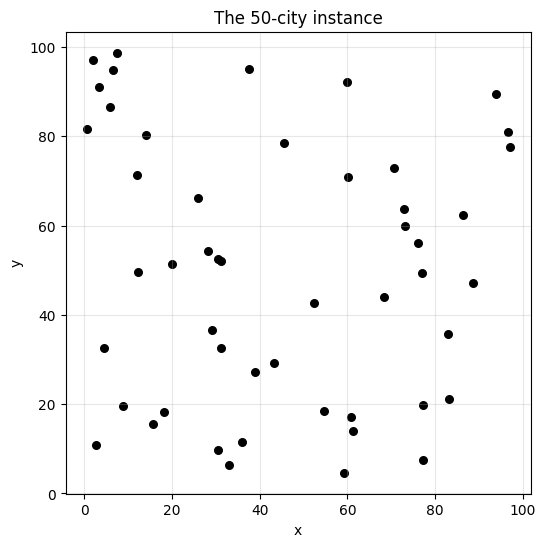

In [2]:
names, coords = load_cities("../data/cities.csv")
dist = distance_matrix(coords)

print(f"Loaded {len(names)} cities")
print(f"Distance matrix shape: {dist.shape}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coords[:, 0], coords[:, 1], s=30, color="black")
ax.set_title("The 50-city instance")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
plt.show()

### The search space

There are `(n - 1)! / 2` distinct tours for a symmetric TSP. For 50 cities that is
around 3 x 10^62, so exhaustive enumeration is not on the table and we are
firmly in heuristic territory.

In [3]:
import math

n = len(names)
print(f"Distinct tours for n = {n}: {math.factorial(n - 1) // 2:.3e}")

rng = np.random.default_rng(MASTER_SEED)
random_lengths = [
    tour_length(list(rng.permutation(n)), dist) for _ in range(1000)
]
print(f"Mean random tour: {np.mean(random_lengths):.2f}")
print(f"Best of 1000 random tours: {np.min(random_lengths):.2f}")

Distinct tours for n = 50: 3.041e+62
Mean random tour: 2695.82
Best of 1000 random tours: 2187.49


## 2. Hill Climbing with random restarts

**Design choices.**

| Choice | Decision | Why |
|---|---|---|
| Candidate adjustment | Steepest ascent | Every move is scored in O(1) by a delta calculation, so a full sweep is cheap and taking the best move gives the fastest descent per iteration |
| Neighbourhood | 2-opt (reverse a segment) | For Euclidean TSP, 2-opt is exactly the move that removes a pair of crossing edges. The naive pairwise-swap neighbourhood disturbs four edges at once and fits the geometry far worse |
| Exploration vs exploitation | Restarts | The climber itself is pure exploitation and always halts at a local optimum. Exploration is reintroduced at the outer level by restarting from a fresh random tour |

Let us watch a single climb first.

Start: 2766.16
Local optimum: 605.77  (42 accepted moves, 0.003 s)


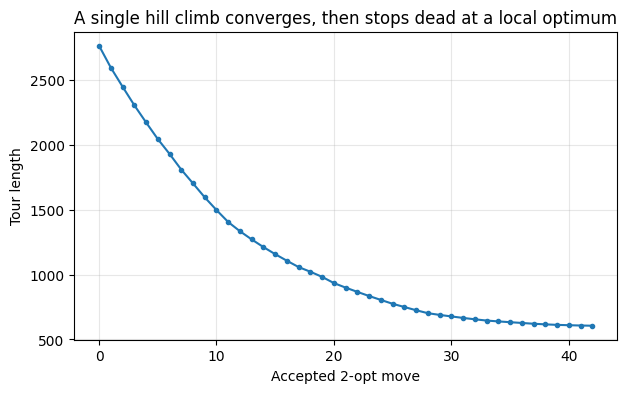

In [4]:
rng = np.random.default_rng(MASTER_SEED)
start = list(rng.permutation(n))

t0 = time.perf_counter()
tour, length, history = hill_climb(start, dist)
elapsed = time.perf_counter() - t0

print(f"Start: {tour_length(start, dist):.2f}")
print(f"Local optimum: {length:.2f}  ({len(history) - 1} accepted moves, {elapsed:.3f} s)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history, marker="o", markersize=3)
ax.set_xlabel("Accepted 2-opt move")
ax.set_ylabel("Tour length")
ax.set_title("A single hill climb converges, then stops dead at a local optimum")
ax.grid(alpha=0.3)
plt.show()

The curve flattens completely: the climber cannot escape. That is the entire
motivation for restarts. How much does the local optimum vary with the starting
point?

50 independent climbs: mean 591.46, best 570.42, worst 618.38


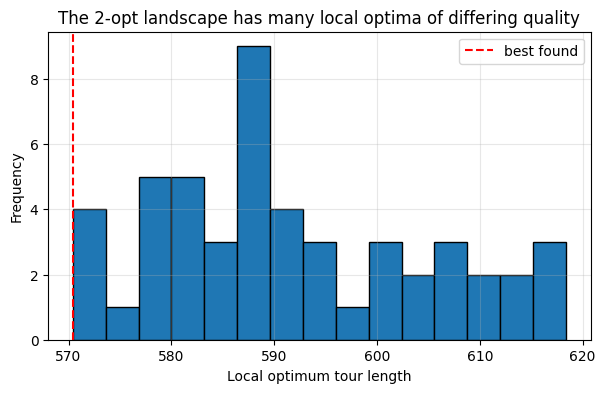

In [5]:
rng = np.random.default_rng(MASTER_SEED)
local_optima = [
    hill_climb(list(rng.permutation(n)), dist)[1] for _ in range(50)
]

print(f"50 independent climbs: mean {np.mean(local_optima):.2f}, "
      f"best {np.min(local_optima):.2f}, worst {np.max(local_optima):.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(local_optima, bins=15, edgecolor="black")
ax.axvline(np.min(local_optima), color="red", linestyle="--", label="best found")
ax.set_xlabel("Local optimum tour length")
ax.set_ylabel("Frequency")
ax.set_title("The 2-opt landscape has many local optima of differing quality")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

The spread is wide, so restarts buy real improvement. Twenty restarts were used
throughout: beyond that the returns flatten while the cost keeps growing linearly.

In [6]:
rng = np.random.default_rng(MASTER_SEED)
t0 = time.perf_counter()
hc_tour, hc_length, hc_history = hill_climb_random_restart(dist, restarts=20, rng=rng)
hc_time = time.perf_counter() - t0

print(f"Hill Climbing (20 restarts): {hc_length:.2f} in {hc_time:.3f} s")

Hill Climbing (20 restarts): 570.42 in 0.065 s


## 3. Genetic Algorithm

**Design choices.**

| Component | Decision | Why |
|---|---|---|
| Representation | Path (permutation of city indices) | Every chromosome is a valid tour by construction, so no repair step is needed |
| Selection | Tournament, size k | Selection pressure is set by one readable parameter and is invariant to the scale of the objective |
| Recombination | Order crossover (OX1) | Preserves both a contiguous block of one parent and the relative order of the other, and always emits a valid permutation |
| Mutation | Inversion (reverse a segment) | This is a 2-opt move applied at random, so the GA and the hill climber explore the *same* move landscape and the comparison isolates search strategy |
| Elitism | Best 4 survive | Guarantees the best-so-far can never get worse |

Sanity-check the operators before trusting them.

In [7]:
rng = np.random.default_rng(MASTER_SEED)
parent_a = list(rng.permutation(8))
parent_b = list(rng.permutation(8))
child = order_crossover(parent_a, parent_b, rng)
mutant = inversion_mutation(child, rng)

print(f"Parent A : {parent_a}")
print(f"Parent B : {parent_b}")
print(f"OX1 child: {child}   valid permutation: {sorted(child) == list(range(8))}")
print(f"Mutated  : {mutant}  valid permutation: {sorted(mutant) == list(range(8))}")

Parent A : [np.int64(3), np.int64(4), np.int64(2), np.int64(7), np.int64(6), np.int64(1), np.int64(5), np.int64(0)]
Parent B : [np.int64(0), np.int64(2), np.int64(7), np.int64(1), np.int64(4), np.int64(5), np.int64(3), np.int64(6)]
OX1 child: [np.int64(0), np.int64(2), np.int64(7), np.int64(4), np.int64(3), np.int64(1), np.int64(5), np.int64(6)]   valid permutation: True
Mutated  : [np.int64(5), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(0), np.int64(6)]  valid permutation: True


Genetic Algorithm: 571.74 in 2.129 s


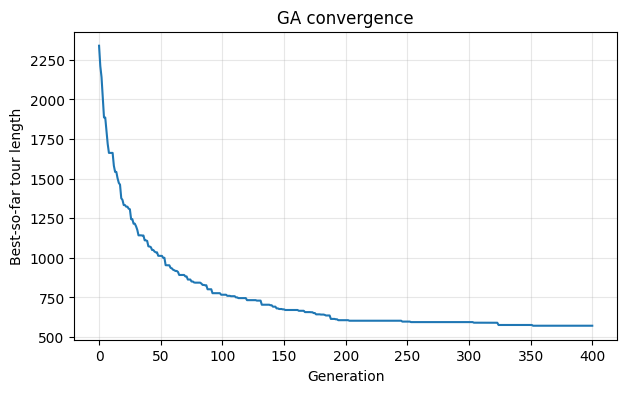

In [8]:
rng = np.random.default_rng(MASTER_SEED)
t0 = time.perf_counter()
ga_tour, ga_length, ga_history = genetic_algorithm(
    dist, population_size=150, generations=400, crossover_rate=0.9,
    mutation_rate=0.2, tournament_size=5, elitism=4, rng=rng,
)
ga_time = time.perf_counter() - t0

print(f"Genetic Algorithm: {ga_length:.2f} in {ga_time:.3f} s")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ga_history)
ax.set_xlabel("Generation")
ax.set_ylabel("Best-so-far tour length")
ax.set_title("GA convergence")
ax.grid(alpha=0.3)
plt.show()

## 4. Tuning the genetic algorithm

Two parameters dominate the exploration/exploitation balance: **tournament size**
(selection pressure) and **mutation rate**. Each configuration is run five times,
because a single run of a stochastic algorithm cannot rank configurations.

In [9]:
grid = [
    {"tournament_size": 2, "mutation_rate": 0.2},
    {"tournament_size": 5, "mutation_rate": 0.2},
    {"tournament_size": 9, "mutation_rate": 0.2},
    {"tournament_size": 5, "mutation_rate": 0.05},
    {"tournament_size": 5, "mutation_rate": 0.5},
    {"tournament_size": 9, "mutation_rate": 0.5},
]

rows = []
for config in grid:
    lengths = []
    for run in range(5):
        rng = np.random.default_rng(MASTER_SEED + run)
        _, length, _ = genetic_algorithm(
            dist, population_size=150, generations=400, crossover_rate=0.9,
            elitism=4, rng=rng, **config,
        )
        lengths.append(length)
    rows.append({**config, "mean": np.mean(lengths), "std": np.std(lengths, ddof=1)})

tuning = pd.DataFrame(rows).sort_values("mean").reset_index(drop=True)
tuning

,tournament_size,mutation_rate,mean,std
0,5,0.500,590.688,17.728
1,9,0.500,590.734,9.988
2,9,0.200,593.871,16.272
3,5,0.200,593.944,21.088
4,5,0.050,605.680,9.364
5,2,0.200,765.912,44.023


## 5. Scalability

Both algorithms are run 30 times at each of 10, 20, 30, 40 and 50 cities. This takes a
few minutes, so the results are loaded from `results/raw_results.csv`, produced by
`python src/experiments.py`.

In [10]:
raw = pd.read_csv("../results/raw_results.csv")

summary = raw.groupby(["size", "algorithm"]).agg(
    mean_distance=("distance", "mean"),
    std_distance=("distance", "std"),
    best_distance=("distance", "min"),
    mean_time=("time", "mean"),
).reset_index()
summary

,size,algorithm,mean_distance,std_distance,best_distance,mean_time
0,10,Genetic Algorithm,290.307,0.000,290.307,1.485
1,10,Hill Climbing,290.307,0.000,290.307,0.005
2,20,Genetic Algorithm,386.522,0.100,386.430,1.637
3,20,Hill Climbing,386.430,0.000,386.430,0.013
4,30,Genetic Algorithm,470.558,15.216,451.767,1.779
5,30,Hill Climbing,452.052,0.738,451.767,0.025
6,40,Genetic Algorithm,524.099,26.618,489.732,1.937
7,40,Hill Climbing,490.037,0.440,489.732,0.047
8,50,Genetic Algorithm,601.078,19.406,568.425,2.108
9,50,Hill Climbing,568.116,6.376,559.865,0.061


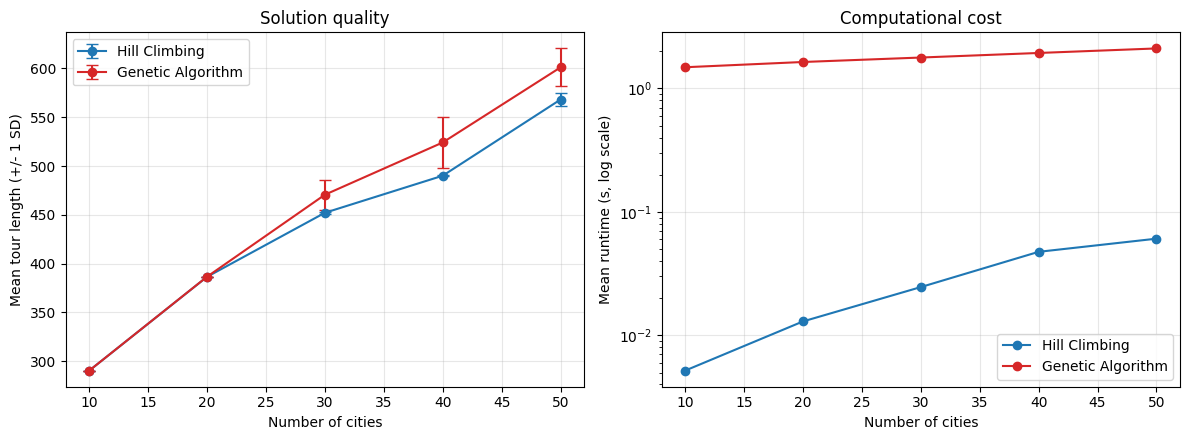

In [11]:
palette = {"Hill Climbing": "#1f77b4", "Genetic Algorithm": "#d62728"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for algorithm, colour in palette.items():
    part = summary[summary["algorithm"] == algorithm]
    axes[0].errorbar(part["size"], part["mean_distance"], yerr=part["std_distance"],
                     marker="o", capsize=4, label=algorithm, color=colour)
    axes[1].plot(part["size"], part["mean_time"], marker="o", label=algorithm,
                 color=colour)
axes[0].set_xlabel("Number of cities")
axes[0].set_ylabel("Mean tour length (+/- 1 SD)")
axes[0].set_title("Solution quality")
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Number of cities")
axes[1].set_ylabel("Mean runtime (s, log scale)")
axes[1].set_yscale("log")
axes[1].set_title("Computational cost")
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Hypothesis testing

Two tests on the 50-city results, because a difference in sample means could be noise.

* **Welch's t-test** does not assume equal variances, which matters here because the GA
  is visibly more variable than the hill climber.
* **Mann-Whitney U** makes no normality assumption at all.

If a parametric and a non-parametric test agree, the conclusion is not an artefact of
either test's assumptions. Cohen's *d* is reported so we can distinguish a
*statistically* significant difference from a *practically* meaningful one.

In [12]:
full = raw[raw["size"] == 50]
hc = full[full["algorithm"] == "Hill Climbing"]["distance"]
ga = full[full["algorithm"] == "Genetic Algorithm"]["distance"]

t_stat, t_p = stats.ttest_ind(hc, ga, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(hc, ga, alternative="two-sided")

pooled = np.sqrt(((len(hc) - 1) * hc.var(ddof=1) + (len(ga) - 1) * ga.var(ddof=1))
                 / (len(hc) + len(ga) - 2))
d = (hc.mean() - ga.mean()) / pooled

print(f"H0: the two algorithms produce tours of equal mean length.\n")
print(f"Hill Climbing    : {hc.mean():.2f} +/- {hc.std(ddof=1):.2f}")
print(f"Genetic Algorithm: {ga.mean():.2f} +/- {ga.std(ddof=1):.2f}\n")
print(f"Welch t-test  : t = {t_stat:.3f}, p = {t_p:.3e}")
print(f"Mann-Whitney U: U = {u_stat:.1f}, p = {u_p:.3e}")
print(f"Cohen's d     : {d:.3f}")

H0: the two algorithms produce tours of equal mean length.

Hill Climbing    : 568.12 +/- 6.38
Genetic Algorithm: 601.08 +/- 19.41

Welch t-test  : t = -8.839, p = 1.844e-10
Mann-Whitney U: U = 19.5, p = 2.039e-10
Cohen's d     : -2.282


## 7. Best route found

The brief requires the tour length printed to the console and the city sequence
written to an external file.

Shortest route found: 570.42


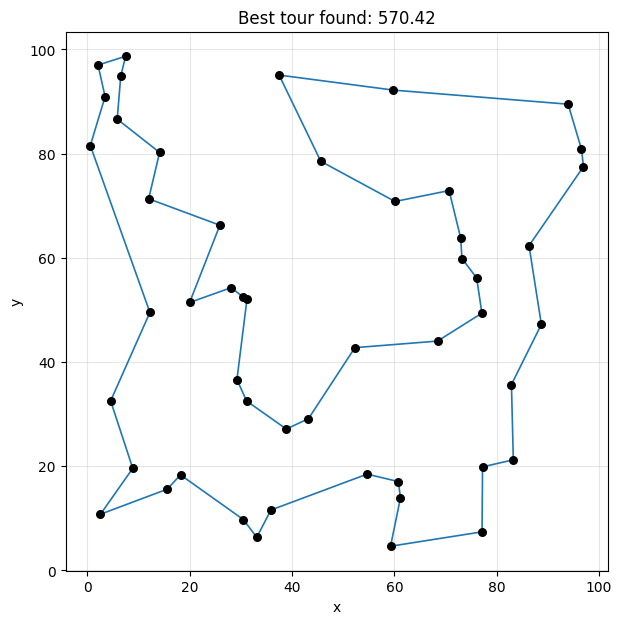

In [13]:
best_tour = hc_tour if hc_length <= ga_length else ga_tour
best_length = min(hc_length, ga_length)

print(f"Shortest route found: {best_length:.2f}")
save_route("../results/best_route.txt", best_tour, names, dist)

closed = list(best_tour) + [best_tour[0]]
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(coords[closed, 0], coords[closed, 1], "-", linewidth=1.2)
ax.scatter(coords[:, 0], coords[:, 1], s=30, color="black", zorder=3)
ax.set_title(f"Best tour found: {best_length:.2f}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
plt.show()